<a href="https://colab.research.google.com/github/robyperez/IA/blob/dev/Copia_de_Taller_Mackey_Glass_time_series_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib as mpl
import seaborn as sns
from matplotlib import pyplot as plt
from itertools import *
import itertools

**Cargar el dataset**

<ipython-input-8-2c4f61c30254>:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('/content/mgdata.dat.txt', header=None, delim_whitespace=True)


   t       x_t
0  0  1.200000
1  1  1.085805
2  2  0.982477
3  3  0.888982
4  4  0.804384


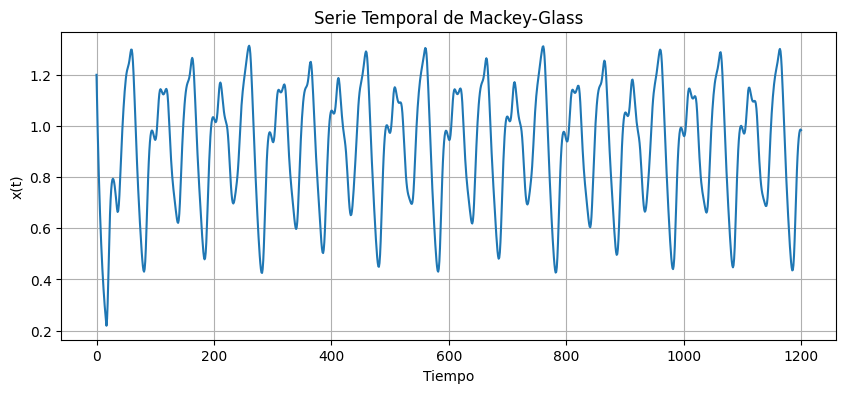

In [ ]:
# Cargar el archivo CSV
df = pd.read_csv('/content/mgdata.dat.txt', header=None, delim_whitespace=True)
df.columns = ['t', 'x_t']

# Visualizar las primeras filas
print(df.head())

# Graficar la serie temporal
plt.figure(figsize=(10, 4))
plt.plot(df['t'], df['x_t'])
plt.title('Serie Temporal de Mackey-Glass')
plt.xlabel('Tiempo')
plt.ylabel('x(t)')
plt.grid(True)
plt.show()

**Explorar los datos**

In [ ]:
df.describe()

,t,x_t
count,1201.000000,1201.000000
mean,600.000000,0.919352
std,346.843144,0.235726
min,0.000000,0.219220
25%,300.000000,0.730704
50%,600.000000,0.967095
75%,900.000000,1.122167
max,1200.000000,1.313696


In [ ]:
# Verificamos si hay valores nulos
nan_count = df['x_t'].isna().sum()
print(f"Cantidad de valores nulos: {nan_count}")


Cantidad de valores nulos: 0


**Dividir en conjunto de entrenamiento y prueba**

In [ ]:
train_size = int(len(df) * 0.7)
data_train = df.iloc[:train_size]
data_test = df.iloc[train_size:]

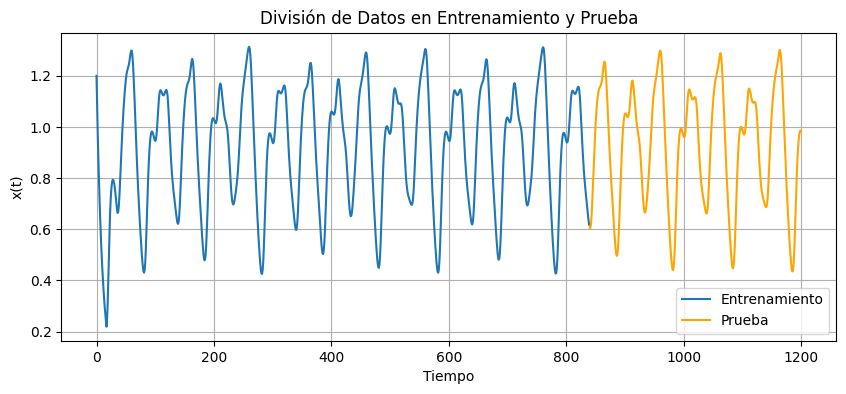

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(data_train['t'], data_train['x_t'], label="Entrenamiento")
plt.plot(data_test['t'], data_test['x_t'], label="Prueba", color='orange')
plt.title("División de Datos en Entrenamiento y Prueba")
plt.xlabel("Tiempo")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


**Crear ventanas deslizantes**

In [ ]:
def sliding_time(data, window_size=1):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])  # Ventana de entrada
        y.append(data[i+window_size])    # Valor futuro
    return np.array(X), np.array(y)


In [ ]:
# Prueba con una lista de ejemplo
a = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
X, y = sliding_time(a, 5)
print("X:", X)
print("y:", y)


X: [[ 1  2  3  4  5]
 [ 2  3  4  5  6]
 [ 3  4  5  6  7]
 [ 4  5  6  7  8]
 [ 5  6  7  8  9]
 [ 6  7  8  9 10]]
y: [ 6  7  8  9 10 11]


In [ ]:
serie_train = data_train['x_t'].values  # Convertir a numpy array
serie_test = data_test['x_t'].values

In [ ]:
WINDOW_SIZE = 10

In [ ]:
X_train, y_train = sliding_time(serie_train, WINDOW_SIZE)
X_test, y_test = sliding_time(serie_test, WINDOW_SIZE)


In [ ]:
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")


Forma de X_train: (830, 10)
Forma de y_train: (830,)
Forma de X_test: (351, 10)
Forma de y_test: (351,)


**Definición y entrenamiento de modelo**

In [ ]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    solver='adam',
    activation='relu',
    hidden_layer_sizes=(120, 40, 10),
    max_iter=500,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    tol=1e-6,
    verbose=True
)


In [ ]:
model.fit(X_train, y_train)


Iteration 1, loss = 0.06315063
Iteration 2, loss = 0.03731622
Iteration 3, loss = 0.01935785
Iteration 4, loss = 0.01651473
Iteration 5, loss = 0.01084873
Iteration 6, loss = 0.00860423
Iteration 7, loss = 0.00539230
Iteration 8, loss = 0.00475251
Iteration 9, loss = 0.00250779
Iteration 10, loss = 0.00173796
Iteration 11, loss = 0.00117910
Iteration 12, loss = 0.00085669
Iteration 13, loss = 0.00074375
Iteration 14, loss = 0.00069823
Iteration 15, loss = 0.00069474
Iteration 16, loss = 0.00069288
Iteration 17, loss = 0.00067686
Iteration 18, loss = 0.00065404
Iteration 19, loss = 0.00062676
Iteration 20, loss = 0.00061338
Iteration 21, loss = 0.00059922
Iteration 22, loss = 0.00058826
Iteration 23, loss = 0.00056095
Iteration 24, loss = 0.00056121
Iteration 25, loss = 0.00054922
Iteration 26, loss = 0.00054395
Iteration 27, loss = 0.00051063
Iteration 28, loss = 0.00048509
Iteration 29, loss = 0.00048133
Iteration 30, loss = 0.00046045
Iteration 31, loss = 0.00044454
Iteration 32, los

MLPRegressor(hidden_layer_sizes=(120, 40, 10), learning_rate='adaptive',
             max_iter=500, tol=1e-06, verbose=True)

**Evaluación del modelo**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error

y_pred = model.predict(X_test)

print(f"Test Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Test Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")


Test Mean Squared Error: 0.0001
Test Mean Absolute Error: 0.0092


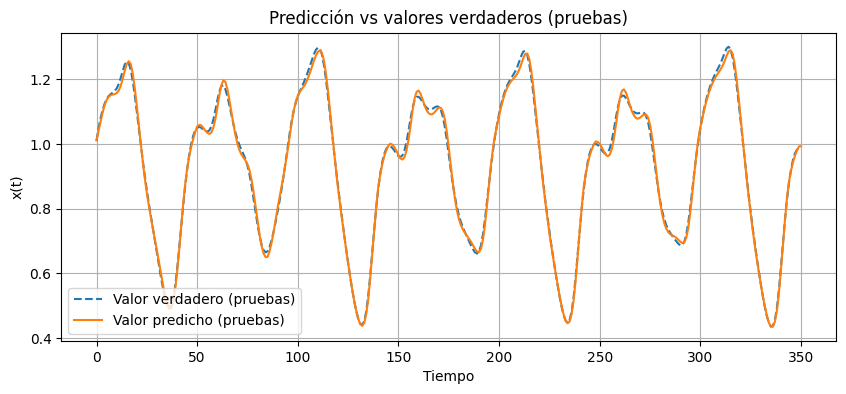

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(range(len(y_test)), y_test, ls="--", label="Valor verdadero (pruebas)")
plt.plot(range(len(y_pred)), y_pred, ls="-", label="Valor predicho (pruebas)")
plt.title("Predicción vs valores verdaderos (pruebas)")
plt.xlabel("Tiempo")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


**Predicción futura**

In [ ]:
ultimos_valores = [serie_test[-WINDOW_SIZE:]]  # Últimos valores de la serie
prediccion_futura = model.predict(ultimos_valores)
print(f"Predicción para el siguiente punto: {prediccion_futura[0]}")


Predicción para el siguiente punto: 0.9884551899990025


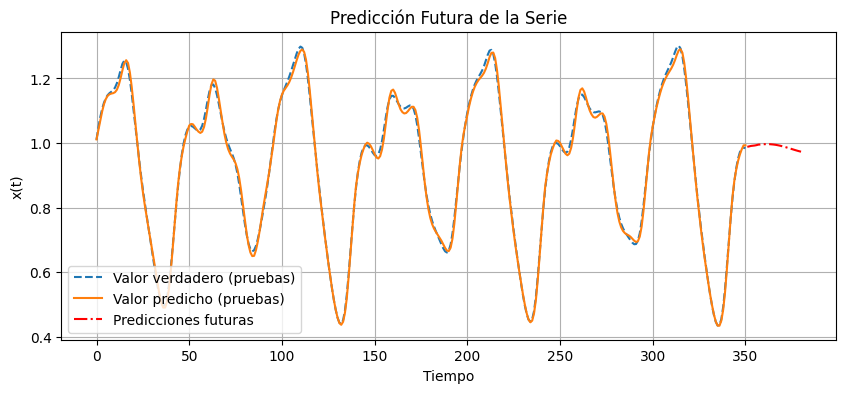

In [ ]:
# Generar predicciones para los próximos 30 pasos
ultimos_valores = list(serie_test[-WINDOW_SIZE:])  # Últimos datos

predicciones_futuras = []

for i in range(30):  # Predecir los próximos 30 puntos
    prediccion = model.predict([ultimos_valores])
    predicciones_futuras.append(prediccion[0])
    ultimos_valores.append(prediccion[0])
    ultimos_valores.pop(0)  # Mantener solo los últimos WINDOW_SIZE valores

# Graficamos las predicciones futuras
plt.figure(figsize=(10, 4))
plt.plot(range(len(y_test)), y_test, ls="--", label="Valor verdadero (pruebas)")
plt.plot(range(len(y_pred)), y_pred, ls="-", label="Valor predicho (pruebas)")
plt.plot(range(len(y_pred), len(y_pred) + len(predicciones_futuras)), predicciones_futuras, ls="-.", label="Predicciones futuras", color='red')
plt.title("Predicción Futura de la Serie")
plt.xlabel("Tiempo")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()
